In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

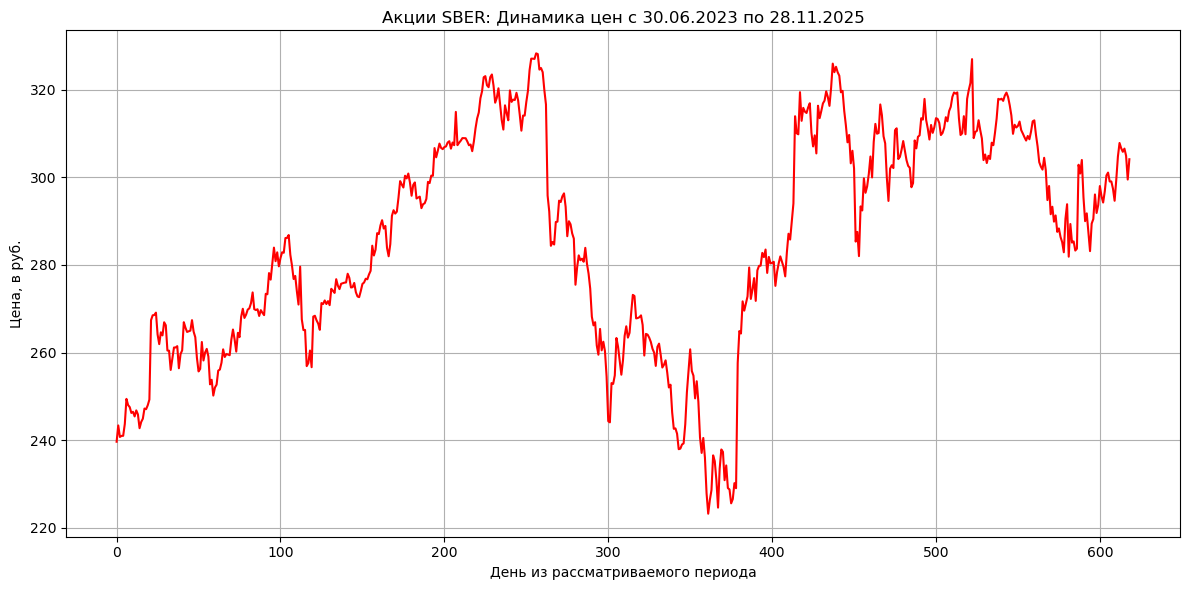

In [2]:
data = pd.read_csv('SBER котировки и доходность.csv', header=0, sep=';')
days = data['DAY']
prices = data['PRICE']
yields = data['YIELD']*100
plt.figure(figsize=(12, 6))
plt.plot(days, prices, color='red')
plt.title(f'Акции SBER: Динамика цен с 30.06.2023 по 28.11.2025')
plt.xlabel('День из рассматриваемого периода')
plt.ylabel('Цена, в руб.')
plt.grid(True)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'ACF')

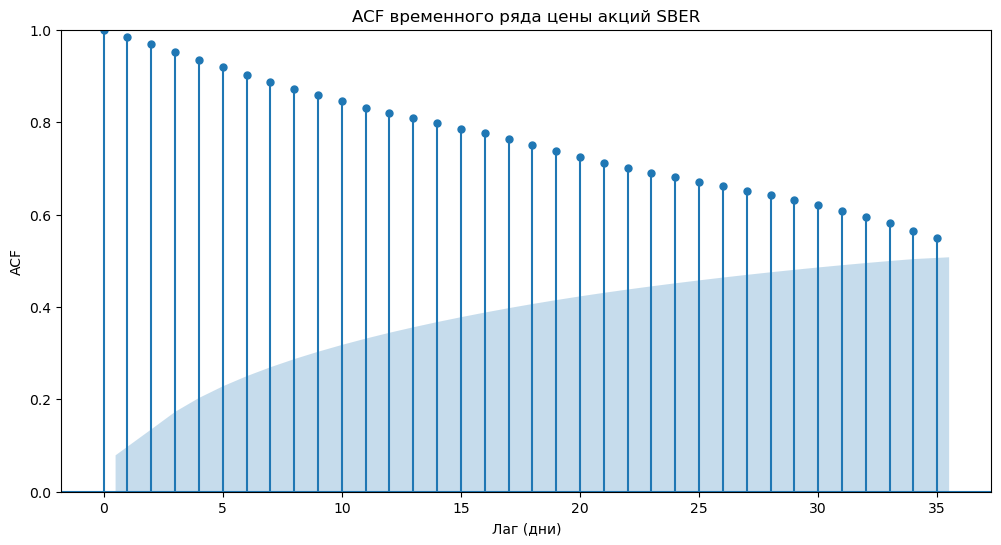

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(prices, lags=35, ax=ax)
ax.set_ylim(bottom=0)
ax.set_title('ACF временного ряда цены акций SBER')
ax.set_xlabel('Лаг (дни)') 
ax.set_ylabel('ACF') 

Text(0, 0.5, 'PACF')

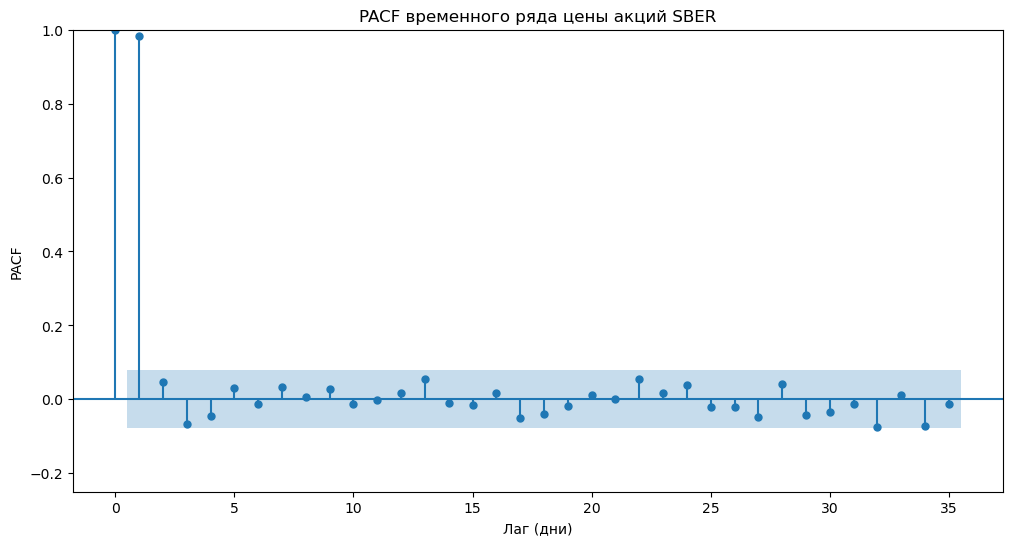

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(prices, lags=35, ax=ax)
ax.set_ylim(bottom=-0.25)
ax.set_title('PACF временного ряда цены акций SBER')
ax.set_xlabel('Лаг (дни)') 
ax.set_ylabel('PACF')

In [5]:
adf_test_trend = adfuller(prices, regression = "ct")
statistic = round(adf_test_trend[0], 4)
P_value = round(adf_test_trend[1], 4)
print(f"Расчётная статистика равна {statistic}; P-значение равно {P_value}")
if P_value > 0.05:
    print("Нулевая гипотеза не отвергается. Расширенный тест Дики-Фулера с константой и трендом показывает нестационарность ряда.")
else:
    print("Нулевая гипотеза отвергается. Расширенный тест Дики-Фулера с константой и трендом показывает стационарность ряда.")

Расчётная статистика равна -2.4309; P-значение равно 0.3633
Нулевая гипотеза не отвергается. Расширенный тест Дики-Фулера с константой и трендом показывает нестационарность ряда.


In [6]:
adf_test = adfuller(prices, regression = "c")
statistic = round(adf_test[0], 4)
P_value = round(adf_test[1], 4)
print(f"Расчётная статистика равна {statistic}; P-значение равно {P_value}")
if P_value > 0.05:
    print("Нулевая гипотеза не отвергается. Расширенный тест Дики-Фулера с константой показывает нестационарность ряда.")
else:
    print("Нулевая гипотеза отвергается. Расширенный тест Дики-Фулера с константой показывает стационарность ряда.")

Расчётная статистика равна -2.3736; P-значение равно 0.1493
Нулевая гипотеза не отвергается. Расширенный тест Дики-Фулера с константой показывает нестационарность ряда.


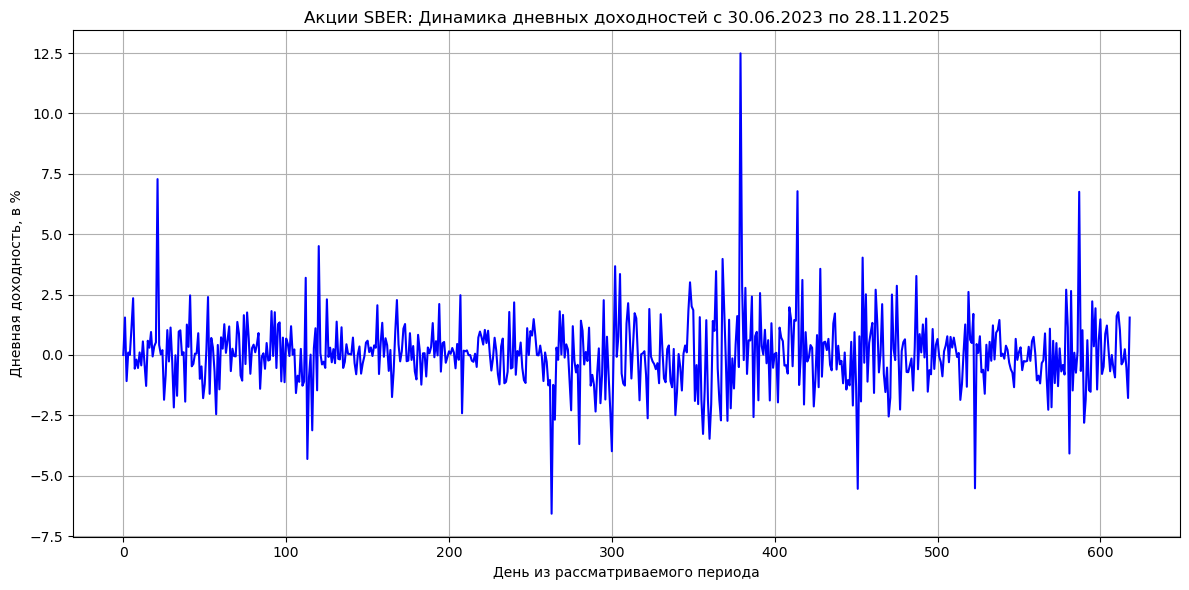

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(days, yields, color='blue')
plt.title(f'Акции SBER: Динамика дневных доходностей с 30.06.2023 по 28.11.2025')
plt.xlabel('День из рассматриваемого периода')
plt.ylabel('Дневная доходность, в %')
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'ACF')

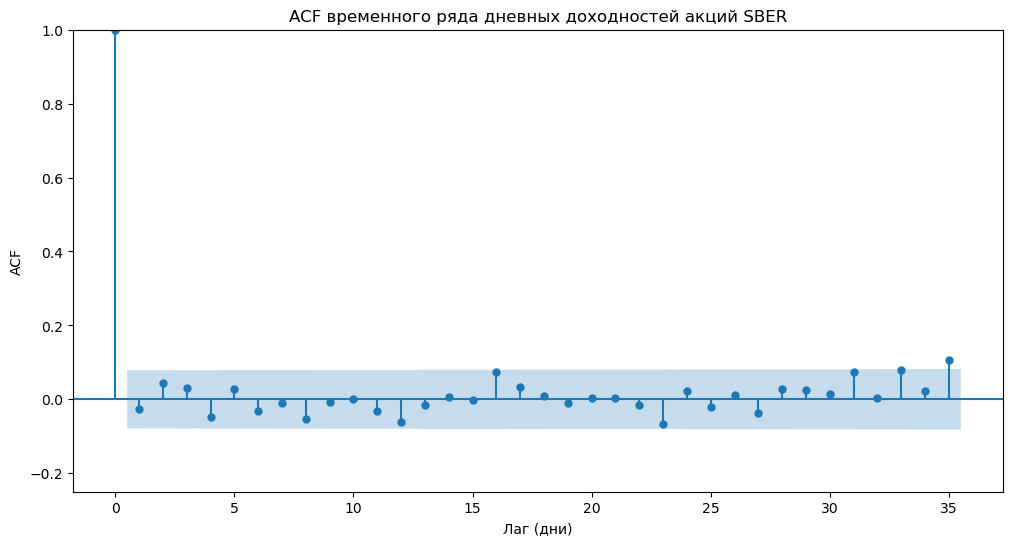

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(yields, lags=35, ax=ax)
ax.set_ylim(bottom=-0.25)
ax.set_title('ACF временного ряда дневных доходностей акций SBER')
ax.set_xlabel('Лаг (дни)') 
ax.set_ylabel('ACF') 

Text(0, 0.5, 'PACF')

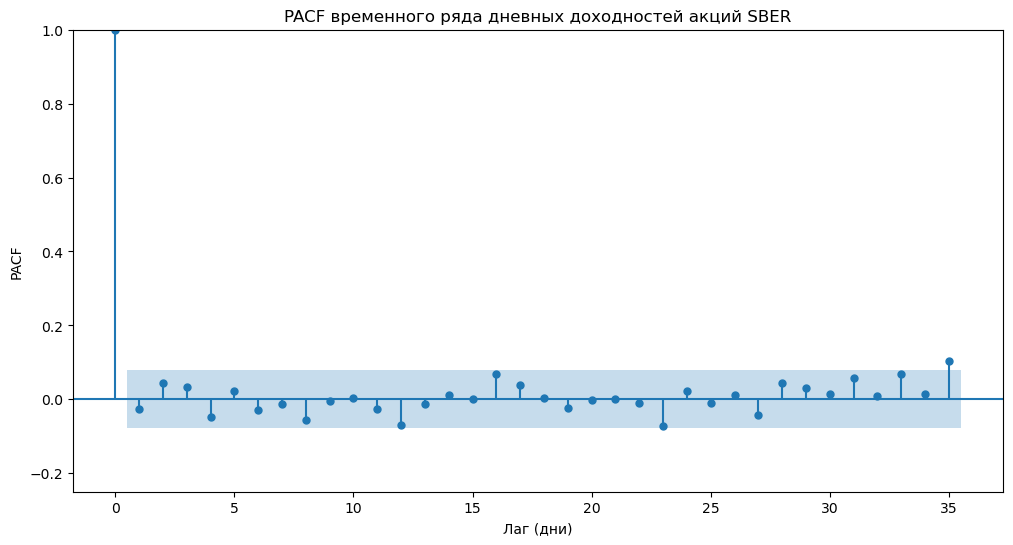

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(yields, lags=35, ax=ax)
ax.set_ylim(bottom=-0.25)
ax.set_title('PACF временного ряда дневных доходностей акций SBER')
ax.set_xlabel('Лаг (дни)') 
ax.set_ylabel('PACF')

In [11]:
adf_test = adfuller(yields, regression = "n")
statistic = round(adf_test[0], 4)
P_value = round(adf_test[1], 9)
print(f"Расчётная статистика равна {statistic}; P-значение равно {P_value}")
if P_value > 0.05:
    print("Нулевая гипотеза не отвергается. Тест Дики-Фулера без константы показывает нестационарность ряда.")
else:
    print("Нулевая гипотеза отвергается. Тест Дики-Фулера без константы показывает стационарность ряда.")

Расчётная статистика равна -25.4796; P-значение равно 0.0
Нулевая гипотеза отвергается. Тест Дики-Фулера без константы показывает стационарность ряда.


In [ ]:
adf_test = adfuller(yields, regression = "c")
statistic = round(adf_test[0], 4)
P_value = round(adf_test[1], 4)
print(f"Расчётная статистика равна {statistic}; P-значение равно {P_value}")
if P_value > 0.05:
    print("Нулевая гипотеза не отвергается. Расширенный тест Дики-Фулера с константой показывает нестационарность ряда.")
else:
    print("Нулевая гипотеза отвергается. Расширенный тест Дики-Фулера с константой показывает стационарность ряда.")

Расчётная статистика равна -25.4882; P-значение равно 0.0
Нулевая гипотеза pтвергается. Расширенный тест Дики-Фулера с константой показывает стационарность ряда.


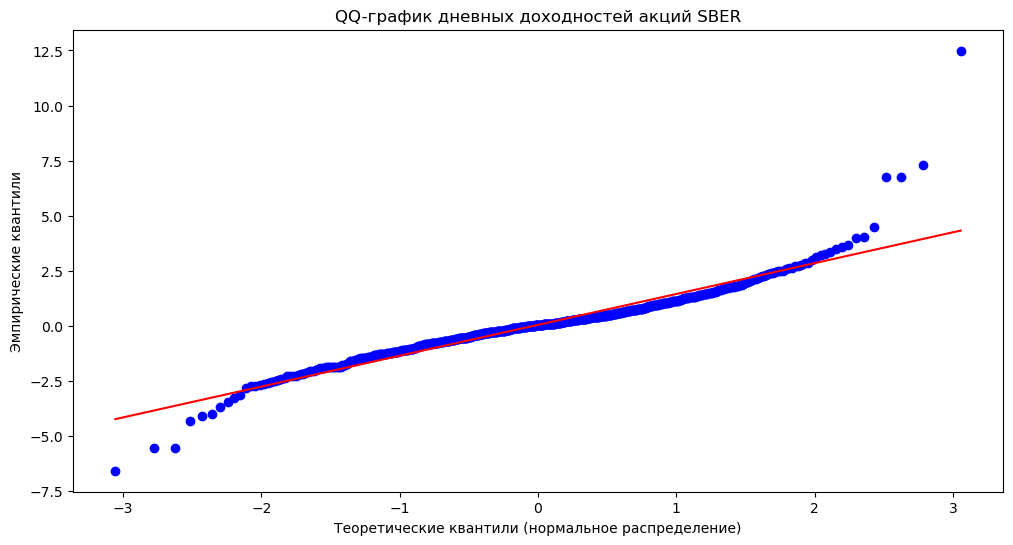

In [16]:
import scipy.stats as stats
plt.figure(figsize=(12, 6))
stats.probplot(yields, dist='norm', plot=plt)
plt.title('QQ-график дневных доходностей акций SBER')
plt.xlabel('Теоретические квантили (нормальное распределение)')  
plt.ylabel('Эмпирические квантили') 
plt.show()

In [17]:
import pmdarima
from pmdarima import arima
ARIMA = arima.auto_arima(yields)
print(ARIMA)
print(ARIMA.summary())

 ARIMA(0,0,0)(0,0,0)[0]          
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  619
Model:                        SARIMAX   Log Likelihood               -1118.167
Date:                Sun, 21 Dec 2025   AIC                           2238.333
Time:                        00:28:27   BIC                           2242.761
Sample:                             0   HQIC                          2240.054
                                - 619                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         2.1705      0.048     44.912      0.000       2.076       2.265
Ljung-Box (L1) (Q):                   0.47   Jarque-Bera (JB):              3206.89
Prob(Q):     

In [18]:
def compare_garch_models(yields, dist=['normal', 'studentst', 'skewstudent'], p_range=(1, 3), q_range=(1, 3)
                         ):
    results = []
    for p in range(p_range[0], p_range[1] + 1):
        for q in range(q_range[0], q_range[1] + 1):
            for d in dist:
                try:
                    model = arch_model(yields, mean='Constant', vol='Garch', 
                                       p=p, q=q, dist=d)
                    fitted = model.fit(disp='off')
                    results.append({
                        'Model': f'GARCH({p},{q})',
                        'Distribution': d,
                        'AIC': fitted.aic,
                        'BIC': fitted.bic,
                        'LogLikelihood': fitted.loglikelihood,
                        'Params': fitted.params,
                        'Fitted': fitted
                    })
                    print(f"✓ GARCH({p},{q}) with {d}: AIC={fitted.aic:.2f}")
                    
                except Exception as e:
                    print(f"✗ GARCH({p},{q}) with {d}: {str(e)[:50]}...")
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('AIC').reset_index(drop=True)
    
    return results_df

In [19]:
print(compare_garch_models(yields, p_range=(1, 5), q_range=(1, 5), dist=['normal', 'studentst', 'skewstudent'])[['Model', 'Distribution', 'AIC', 'BIC']])

✓ GARCH(1,1) with normal: AIC=2212.30
✓ GARCH(1,1) with studentst: AIC=2060.27
✓ GARCH(1,1) with skewstudent: AIC=2061.79
✓ GARCH(1,2) with normal: AIC=2214.30
✓ GARCH(1,2) with studentst: AIC=2061.91
✓ GARCH(1,2) with skewstudent: AIC=2063.47
✓ GARCH(1,3) with normal: AIC=2216.30
✓ GARCH(1,3) with studentst: AIC=2063.91
✓ GARCH(1,3) with skewstudent: AIC=2065.47
✓ GARCH(1,4) with normal: AIC=2218.30
✓ GARCH(1,4) with studentst: AIC=2065.91
✓ GARCH(1,4) with skewstudent: AIC=2067.47
✓ GARCH(1,5) with normal: AIC=2217.04
✓ GARCH(1,5) with studentst: AIC=2067.91
✓ GARCH(1,5) with skewstudent: AIC=2069.47
✓ GARCH(2,1) with normal: AIC=2214.16
✓ GARCH(2,1) with studentst: AIC=2062.27
✓ GARCH(2,1) with skewstudent: AIC=2063.79
✓ GARCH(2,2) with normal: AIC=2214.65
✓ GARCH(2,2) with studentst: AIC=2063.89
✓ GARCH(2,2) with skewstudent: AIC=2065.44
✓ GARCH(2,3) with normal: AIC=2216.65
✓ GARCH(2,3) with studentst: AIC=2065.89
✓ GARCH(2,3) with skewstudent: AIC=2067.44
✓ GARCH(2,4) with normal

In [20]:
GARCH = arch_model(yields, mean='Constant', vol='Garch', 
                                       p=1, q=1, dist='studentsT')
FIT = GARCH.fit(disp='off')
FIT.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                        YIELD   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1025.13
Distribution:      Standardized Student's t   AIC:                           2060.27
Method:                  Maximum Likelihood   BIC:                           2082.41
                                              No. Observations:                  619
Date:                      Sun, Dec 21 2025   Df Residuals:                      618
Time:                              00:29:23   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0363  4.362e-02      0.833      0.405 [-4.917e-02,  0.122]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1407  6.372e-02      2.208  2.725e-02 [1.580e-02,  0.266]
alpha[1]       0.1133  5.008e-02      2.263  2.363e-02 [1.518e-02,  0.212]
beta[1]        0.8356  5.332e-02     15.671  2.402e-55   [  0.731,  0.940]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             3.5846      0.611      5.865  4.491e-09 [  2.387,  4.782]
========================================================================

Covariance estimator: robust
"""

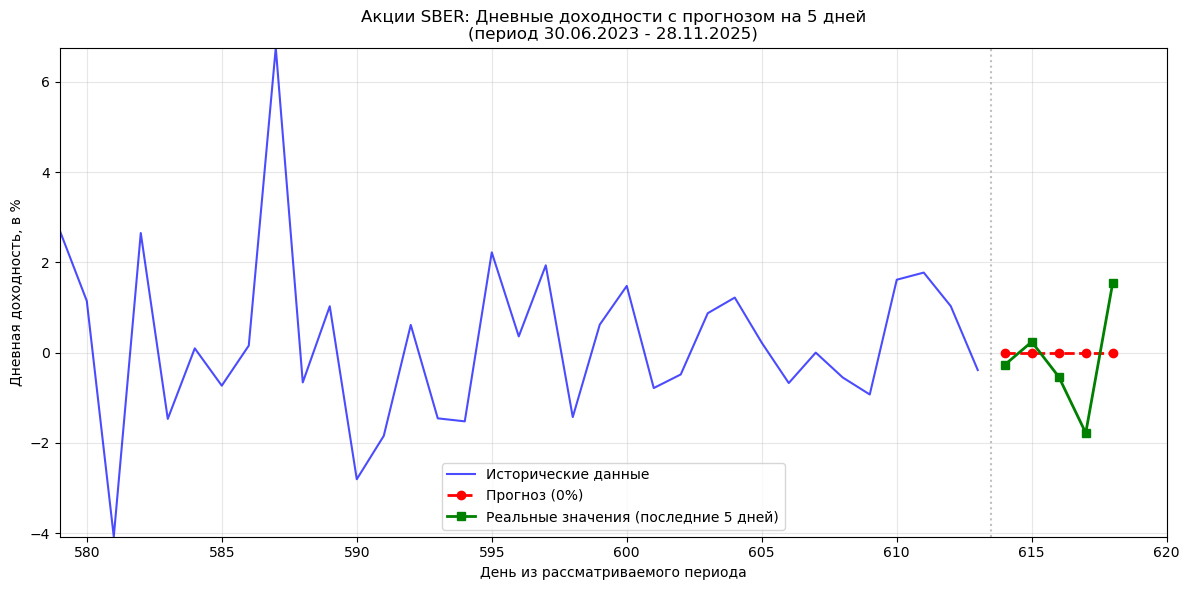

In [21]:
last_5_idx = -5
days_without_last_5 = days[:last_5_idx]
yields_without_last_5 = yields[:last_5_idx]


forecast_days = np.arange(len(days) - 5, len(days))
forecast_values = np.zeros(5)


actual_last_5_days = days[last_5_idx:]
actual_last_5_values = yields[last_5_idx:]

plt.figure(figsize=(12, 6))


plt.plot(days_without_last_5, yields_without_last_5, 
         color='blue', alpha=0.7, label='Исторические данные')


plt.plot(forecast_days, forecast_values, 
         color='red', linestyle='--', linewidth=2, 
         marker='o', markersize=6, label='Прогноз (0%)')


plt.plot(actual_last_5_days, actual_last_5_values, 
         color='green', linestyle='-', linewidth=2,
         marker='s', markersize=6, label='Реальные значения (последние 5 дней)')


plt.axvline(x=len(days)-5.5, color='gray', linestyle=':', alpha=0.5)

plt.title(f'Акции SBER: Дневные доходности с прогнозом на 5 дней\n(период 30.06.2023 - 28.11.2025)')
plt.xlabel('День из рассматриваемого периода')
plt.ylabel('Дневная доходность, в %')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


plt.xlim([len(days)-40, len(days)+1])  
plt.ylim([min(min(yields[-40:]), -0.5), max(max(yields[-40:]), 0.5)])

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
fact = yields[-5:]
prognoz = np.zeros(5)
rmse = root_mean_squared_error(fact, prognoz)
print(f'RMSE = {rmse}')
mae = mean_absolute_error(fact, prognoz)
print(f'MAE = {mae}')

RMSE = 1.0942032425527006
MAE = 0.87476804


In [ ]:
from scipy.stats import norm, chi2

alpha = 0.05
N = 500

returns = yields.dropna().reset_index(drop=True)

VaR = np.zeros(len(returns) - N)
test_returns = returns[N:].reset_index(drop=True)

for i in range(N, len(returns)):
    train = returns[i - N:i]

    #ARIMA(0,0,0)
    model = arch_model(
        train,
        mean='Constant',
        vol='Garch',
        p=1, q=1,
        dist='studentsT'
    )

    fit = model.fit(disp='off')

    forecast = fit.forecast(horizon=1)

    mu = forecast.mean.iloc[-1, 0]
    sigma = np.sqrt(forecast.variance.iloc[-1, 0])

    VaR[i - N] = mu + sigma * norm.ppf(alpha)

#### ГРАФИК ####
plt.figure(figsize=(12, 6))
plt.plot(test_returns.values, color='black', linewidth=0.8, label='Доходности')
plt.plot(VaR, color='red', linewidth=1.5, label='VaR (5%)')

plt.title('Value-at-Risk: ARIMA(0,0,0) + GARCH(1,1)')
plt.xlabel('Время')
plt.ylabel('Доходность')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### ТЕСТ КУПИКА ####
L = len(test_returns)
K = np.sum(test_returns.values < VaR)

a0 = K / L
a = alpha

LR_uc = -2 * (np.log((1 - a) ** (L - K) * a ** K) - np.log((1 - a0) ** (L - K) * a0 ** K))
p_value = 1 - chi2.cdf(LR_uc, df=1)

print(f'Число наблюдений L = {L}')
print(f'Число пробитий K = {K}')
print(f'Эмпирическая доля пробитий a0 = {a0:.4f}')
print(f'LR статистика Купика = {LR_uc:.4f}')
print(f'p-value = {p_value:.4f}')

if p_value > 0.05:
    print('Нулевая гипотеза НЕ отвергается: VaR адекватен')
else:
    print('Нулевая гипотеза отвергается: VaR неадекватен')